# SIIM-ISIC Mean Probability Model Submission

Submit a mean probability model (using pre-extracted features) to Kaggle.

### Expected Kaggle format

Please upload the following (as a private dataset) to Kaggle as 'siim-isic-mean-blend-assets.zip':

```text
siim-isic-mean-blend-assets/
├── feature_cache/
│   ├── b7_joint_meta_train_features.npz              # optional: validation
│   ├── b7_joint_meta_test_features.npz               # REQUIRED: submission
│   ├── effb0_hybrid14_supcon_train_features.npz      # optional: validation
│   └── effb0_hybrid14_supcon_test_features.npz       # REQUIRED: submission
└── checkpoints/                                      # optional: reproducibility
    ├── best_model_b7_joint_meta.pth
    └── effb0_hybrid14_supcon_fold2_best_model.pth
```

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedShuffleSplit

import matplotlib.pyplot as plt


In [ ]:
# Config
SEED = 42
BLEND_VALID_FRACTION = 0.10
RUN_VALIDATION = True # auto skipped if train caches are absent.

COMP_DIR = Path("/kaggle/input/competitions/siim-isic-melanoma-classification")
ASSET_DIR = Path("/kaggle/input/datasets/omargrist/siim-isic-mean-blend-assets")
FEATURE_DIR = ASSET_DIR / "feature_cache"
WORK_DIR = Path("/kaggle/working")

SAMPLE_SUBMISSION = COMP_DIR / "sample_submission.csv"
SUBMISSION_PATH = WORK_DIR / "submission.csv"

MODEL_CACHES = [
    {
        "name": "b7_joint_meta",
        "train": FEATURE_DIR / "b7_joint_meta_train_features.npz",
        "test": FEATURE_DIR / "b7_joint_meta_test_features.npz",
    },
    {
        "name": "effb0_hybrid14_supcon",
        "train": FEATURE_DIR / "effb0_hybrid14_supcon_train_features.npz",
        "test": FEATURE_DIR / "effb0_hybrid14_supcon_test_features.npz",
    },
]

print("Competition dir:", COMP_DIR)
print("Asset dir:", ASSET_DIR)
print("Feature dir:", FEATURE_DIR)
print("Working dir:", WORK_DIR)


Competition dir: /kaggle/input/competitions/siim-isic-melanoma-classification
Asset dir: /kaggle/input/datasets/omargrist/siim-isic-mean-blend-assets
Feature dir: /kaggle/input/datasets/omargrist/siim-isic-mean-blend-assets/feature_cache
Working dir: /kaggle/working


In [3]:
# Input checks
required = [SAMPLE_SUBMISSION] + [spec["test"] for spec in MODEL_CACHES]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(f"Missing required Kaggle input files:{' + '.join(missing)}")

print("Required submission inputs found.")
for spec in MODEL_CACHES:
    print(f"{spec['name']}: train_cache={spec['train'].exists()} | test_cache={spec['test'].exists()}")


Required submission inputs found.
b7_joint_meta: train_cache=True | test_cache=True
effb0_hybrid14_supcon: train_cache=True | test_cache=True


In [4]:
# Cache loading and validation
REQUIRED_CACHE_KEYS = {"image_name", "patient_id", "probs"}


def load_cache(path, split):
    data = np.load(path, allow_pickle=True)
    keys = set(data.files)
    missing = REQUIRED_CACHE_KEYS - keys
    if missing:
        raise KeyError(f"{path.name} missing required keys: {sorted(missing)}. Found: {sorted(keys)}")

    image_name = data["image_name"].astype(str)
    patient_id = data["patient_id"].astype(str)
    probs = data["probs"].astype(np.float32)

    if probs.ndim != 1:
        probs = probs.reshape(-1)

    if len(image_name) != len(probs):
        raise ValueError(f"{path.name}: image_name/probs length mismatch: {len(image_name)} vs {len(probs)}")
    if len(set(image_name)) != len(image_name):
        raise ValueError(f"{path.name}: duplicate image_name values detected")
    if not np.isfinite(probs).all():
        raise ValueError(f"{path.name}: probabilities contain NaN/Inf")
    if probs.min() < -1e-6 or probs.max() > 1 + 1e-6:
        raise ValueError(f"{path.name}: probabilities outside [0, 1]: min={probs.min()}, max={probs.max()}")

    out = {
        "path": path,
        "split": split,
        "image_name": image_name,
        "patient_id": patient_id,
        "probs": np.clip(probs, 0.0, 1.0),
    }

    if split == "train":
        if "target" not in keys:
            raise KeyError(f"{path.name}: train cache is missing target")
        target = data["target"].astype(np.float32).reshape(-1)
        if len(target) != len(probs):
            raise ValueError(f"{path.name}: target/probs length mismatch")
        out["target"] = target

    return out


def merge_model_probs(cache_items, split):
    ref = cache_items[0]
    order = ref["image_name"]
    probs = []

    for item in cache_items:
        pos = pd.Series(np.arange(len(item["image_name"])), index=item["image_name"])
        if not set(order).issubset(set(item["image_name"])):
            missing = sorted(set(order) - set(item["image_name"]))[:5]
            raise ValueError(f"{item['path'].name}: missing image_names from reference order, examples={missing}")
        idx = pos.loc[order].values
        probs.append(item["probs"][idx][:, None])

    meta = pd.DataFrame({
        "image_name": order,
        "patient_id": ref["patient_id"],
    })

    if split == "train":
        meta["target"] = ref["target"].astype(int)

    base_probs = np.concatenate(probs, axis=1).astype(np.float32)
    print(f"Merged {split}: base_probs={base_probs.shape}")
    return base_probs, meta


In [ ]:
sample_submission = pd.read_csv(SAMPLE_SUBMISSION)
print("Sample submission:", sample_submission.shape, list(sample_submission.columns))

if list(sample_submission.columns) != ["image_name", "target"]:
    raise ValueError(f"Unexpected sample_submission columns: {list(sample_submission.columns)}")

test_items = [load_cache(spec["test"], split="test") for spec in MODEL_CACHES]
base_probs_test, meta_test = merge_model_probs(test_items, split="test")

test_blend = base_probs_test.mean(axis=1).astype(np.float32)

pred = pd.DataFrame({
    "image_name": meta_test["image_name"].values,
    "target": np.clip(test_blend, 0.0, 1.0),
})

submission = sample_submission[["image_name"]].merge(pred, on="image_name", how="left")

if submission["target"].isna().any():
    missing = submission.loc[submission["target"].isna(), "image_name"].head().tolist()
    raise ValueError(f"Missing predictions for sample_submission rows, examples={missing}")
if len(submission) != len(sample_submission):
    raise ValueError("Submission row count changed during merge")
if list(submission.columns) != ["image_name", "target"]:
    raise ValueError(f"Submission columns are wrong: {list(submission.columns)}")

submission.to_csv(SUBMISSION_PATH, index=False)
print(f"Saved Kaggle submission: {SUBMISSION_PATH}")
print(submission.head())
print(submission["target"].describe())


Sample submission: (10982, 2) ['image_name', 'target']
Merged test: base_probs=(10982, 2)
Saved Kaggle submission: /kaggle/working/submission.csv
     image_name    target
0  ISIC_0052060  0.032760
1  ISIC_0052349  0.048792
2  ISIC_0058510  0.016668
3  ISIC_0073313  0.011009
4  ISIC_0073502  0.028616
count    10982.000000
mean         0.123235
std          0.152652
min          0.004196
25%          0.030364
50%          0.059535
75%          0.154400
max          0.986023
Name: target, dtype: float64


## Validation and threshold tuning (if enabled)

In [ ]:
def split_blend_validation(meta):
    patient_targets = meta.groupby("patient_id")["target"].max().reset_index()
    splitter = StratifiedShuffleSplit(
        n_splits=1,
        test_size=BLEND_VALID_FRACTION,
        random_state=SEED,
    )
    _, val_idx = next(splitter.split(patient_targets["patient_id"], patient_targets["target"]))
    val_patients = set(patient_targets.iloc[val_idx]["patient_id"])
    return meta["patient_id"].isin(val_patients).values


def safe_auc(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    if len(np.unique(y_true)) < 2:
        return np.nan, np.nan
    return roc_auc_score(y_true, y_prob), average_precision_score(y_true, y_prob)


def evaluate_predictions(y_true, y_prob, name="mean_base_blend", threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=np.float32)
    y_pred = (y_prob >= threshold).astype(int)

    auc, auprc = safe_auc(y_true, y_prob)
    metrics = {
        "model": name,
        "threshold": float(threshold),
        "auc": auc,
        "auprc": auprc,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
    }

    print(f"{name} AUC:   {metrics['auc']:.5f}")
    print(f"{name} AUPRC: {metrics['auprc']:.5f}")
    print(f"{name} Acc:   {metrics['accuracy']:.5f}")
    print(f"{name} F1:    {metrics['f1']:.5f}")
    print(classification_report(y_true, y_pred, target_names=["Benign", "Melanoma"]))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks([0, 1], ["Benign", "Melanoma"])
    plt.yticks([0, 1], ["Benign", "Melanoma"])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(WORK_DIR / f"confusion_matrix_{name}.png", dpi=150)
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}", lw=2)
    plt.plot([0, 1], [0, 1], "--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(WORK_DIR / f"roc_curve_{name}.png", dpi=150)
    plt.show()

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUPRC = {auprc:.4f}", lw=2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(WORK_DIR / f"pr_curve_{name}.png", dpi=150)
    plt.show()

    return metrics


def find_best_threshold(y_true, y_prob):
    rows = []
    for th in np.linspace(0.01, 0.99, 999):
        pred = (y_prob >= th).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
        precision = tp / max(1, tp + fp)
        recall = tp / max(1, tp + fn)
        f1 = f1_score(y_true, pred)
        rows.append({
            "threshold": th,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "tp": tp,
            "fp": fp,
            "tn": tn,
            "fn": fn,
        })

    df = pd.DataFrame(rows)
    return df.sort_values("f1", ascending=False).iloc[0], df


Merged train: base_probs=(33126, 2)
mean_base_probability_blend AUC:   0.97664
mean_base_probability_blend AUPRC: 0.45333
mean_base_probability_blend Acc:   0.97332
mean_base_probability_blend F1:    0.41379
              precision    recall  f1-score   support

      Benign       0.99      0.98      0.99      3130
    Melanoma       0.34      0.54      0.41        56

    accuracy                           0.97      3186
   macro avg       0.66      0.76      0.70      3186
weighted avg       0.98      0.97      0.98      3186



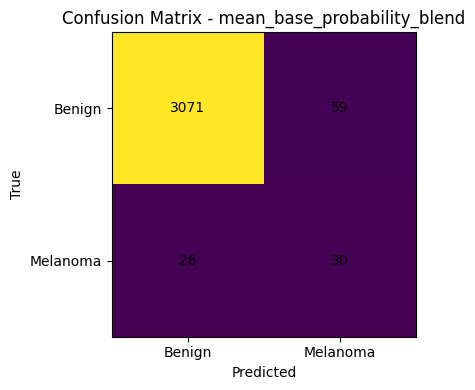

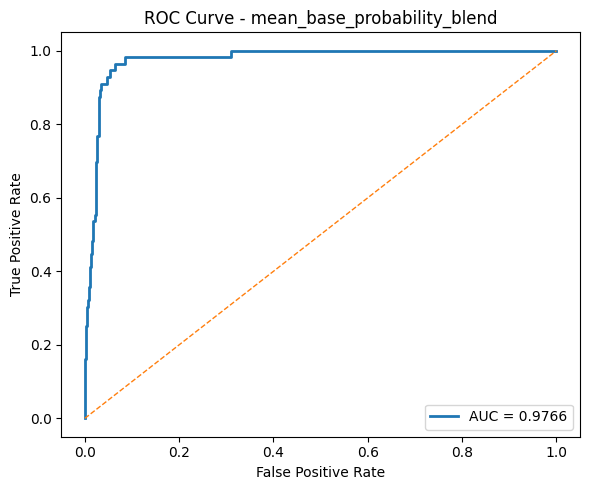

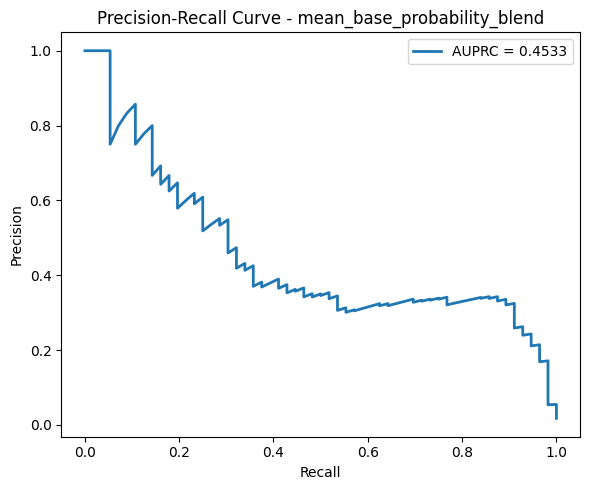

threshold       0.429299
precision       0.340278
recall          0.875000
f1              0.490000
tp             49.000000
fp             95.000000
tn           3035.000000
fn              7.000000
Name: 427, dtype: float64
mean_base_probability_blend_best_threshold AUC:   0.97664
mean_base_probability_blend_best_threshold AUPRC: 0.45333
mean_base_probability_blend_best_threshold Acc:   0.96798
mean_base_probability_blend_best_threshold F1:    0.49000
              precision    recall  f1-score   support

      Benign       1.00      0.97      0.98      3130
    Melanoma       0.34      0.88      0.49        56

    accuracy                           0.97      3186
   macro avg       0.67      0.92      0.74      3186
weighted avg       0.99      0.97      0.97      3186



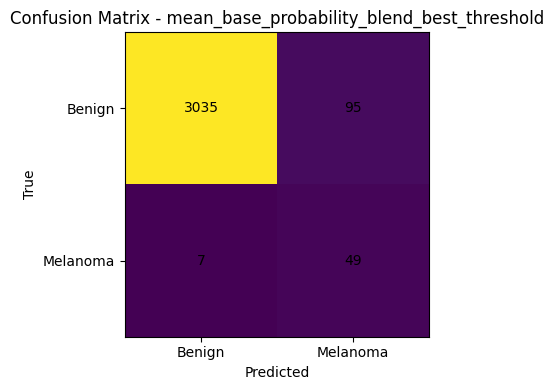

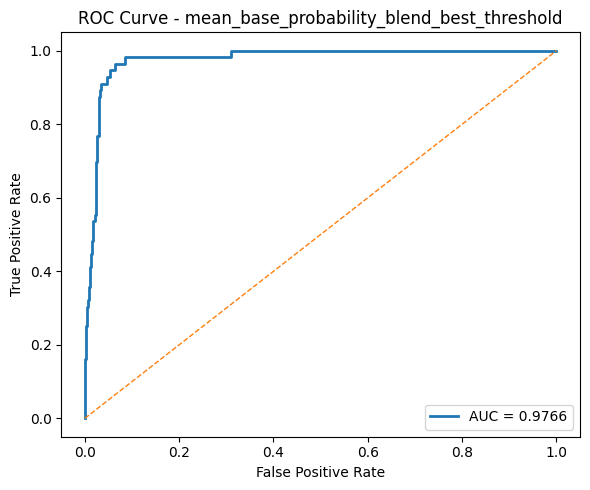

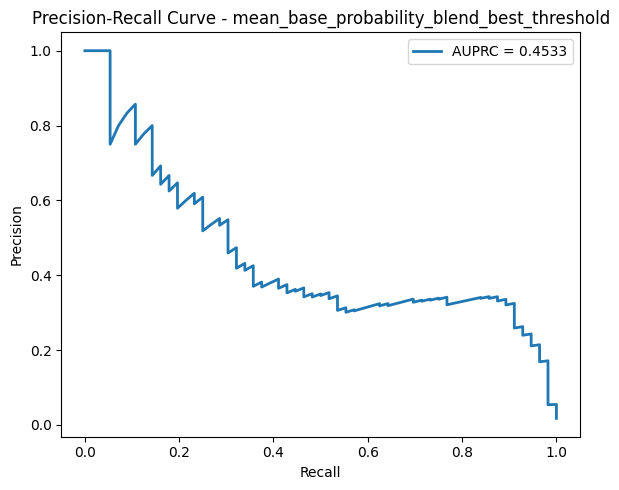

In [ ]:
# Validation run
train_paths_present = all(spec["train"].exists() for spec in MODEL_CACHES)

if RUN_VALIDATION and train_paths_present:
    train_items = [load_cache(spec["train"], split="train") for spec in MODEL_CACHES]
    base_probs_train, meta_train = merge_model_probs(train_items, split="train")

    train_blend = base_probs_train.mean(axis=1).astype(np.float32)
    val_mask = split_blend_validation(meta_train)
    val_meta = meta_train[val_mask].reset_index(drop=True)
    val_probs = train_blend[val_mask]
    y_val = val_meta["target"].values.astype(int)

    metrics_05 = evaluate_predictions(
        y_val,
        val_probs,
        name="mean_base_probability_blend",
        threshold=0.5,
    )

    valid_pred = val_meta[["image_name", "target", "patient_id"]].copy()
    valid_pred["pred"] = val_probs
    valid_pred.to_csv(WORK_DIR / "valid_predictions_mean_base_blend.csv", index=False)

    best_row, threshold_df = find_best_threshold(y_val, val_probs)
    print(best_row)
    threshold_df.to_csv(WORK_DIR / "threshold_sweep_mean_base_blend.csv", index=False)

    metrics_best = evaluate_predictions(
        y_val,
        val_probs,
        name="mean_base_probability_blend_best_threshold",
        threshold=float(best_row["threshold"]),
    )

    pd.DataFrame([metrics_05, metrics_best]).to_csv(
        WORK_DIR / "mean_blend_validation_metrics.csv",
        index=False,
    )
else:
    print("Validation skipped. Set RUN_VALIDATION=True and upload both train feature caches to enable it.")


In [8]:
# Final file check
submission_check = pd.read_csv(SUBMISSION_PATH)
print(SUBMISSION_PATH)
print(submission_check.shape)
print(submission_check.head())

assert list(submission_check.columns) == ["image_name", "target"]
assert len(submission_check) == len(pd.read_csv(SAMPLE_SUBMISSION))
assert submission_check["target"].between(0, 1).all()
assert not submission_check["target"].isna().any()
print("submission.csv is ready for Kaggle.")


/kaggle/working/submission.csv
(10982, 2)
     image_name    target
0  ISIC_0052060  0.032760
1  ISIC_0052349  0.048792
2  ISIC_0058510  0.016668
3  ISIC_0073313  0.011009
4  ISIC_0073502  0.028616
submission.csv is ready for Kaggle.
